# Part 1 (a)

In [1]:
#Importing necessary packages

import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import norm

import seaborn as sns

In [2]:
#Define the given probability density function f(x) that represents the distribution to simulate random numbers for the distribution

def f(x):
    return 0.5 * np.exp(-np.abs(x))

In [3]:
#Set up the initial parameters required for the Metropolis-Hastings Algorithm

N = 10000
s = 1
x_0 = 0

In [4]:
#Implement the Metropolis-Hastings Algorithm to generate a sequence of samples of random numbers for the distribution with probability density function f(x)

def metropolis_hastings(N, s, x_0):
    x = np.zeros(N)
    x[0] = x_0
    
    for i in range(1, N):
        x_star = np.random.normal(x[i-1], s)
        
        # Calculate
        
        fx_star = f(x_star)
        fx_prev = f(x[i-1])
        
        # Compute the ratio
        
        ratio = fx_star / fx_prev
        
        # Generate random number u
        
        u = np.random.uniform()
        
        # Compare u and r(x_star, x_(i-1))
        
        if u < ratio:
            x[i] = x_star
        else:
            x[i] = x[i-1]
    
    return x

In [6]:
#Generate samples using the Metropolis-Hastings Algorithm

samples = metropolis_hastings(N, s, x_0)

In [7]:
#Calculate sample mean of the generated samples

sample_mean = np.mean(samples)
print("Sample Mean:", sample_mean)

Sample Mean: -0.12391798128142836


In [8]:
#Calculate standard deviation of the generated samples

sample_sd = np.std(samples)
print("Standard Deviation:", sample_sd)

Standard Deviation: 1.4029509533591855


### Plotting Histogram, Kernel Density Estimate and f(x) on the same graph

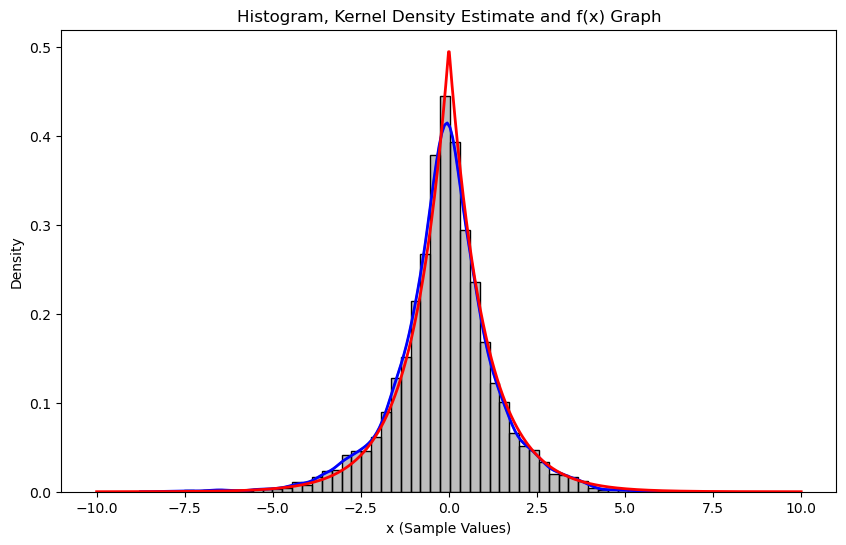

In [9]:
#Create a new figure

plt.figure(figsize=(10, 6))

#Plot histogram with KDE

sns.histplot(samples, kde=True, color='grey', stat='density', bins=50)
sns.kdeplot(samples, color='blue', linewidth=2)

#Generate x values for f(x) curve

x_values = np.linspace(-10, 10, 1000)

#Evaluate f(x) for x_values

f_values = f(x_values)

#Overlay f(x) graph

plt.plot(x_values, f_values, color='red', linewidth=2)

#Set plot labels and title

plt.xlabel('x (Sample Values)')
plt.ylabel('Density')
plt.title('Histogram, Kernel Density Estimate and f(x) Graph')

#Show plot

plt.show()


# Part 1 (b)

In [10]:
#Set up the parameters required for calculating R-hat values

N = 2000
J = 4
s = 0.001
s_values = np.arange(0.001, 1.001, 0.001)

In [11]:
#Define the Metropolis-Hastings Algorithm to generate multiple chains of samples using different initial values and compute the R-hat values

def generate_chains(N, s, J):
    r_hat_values = []
    
    for s_val in s_values:
        chains = np.zeros((N, J))
        
        #Generate J chains with different initial values
        
        for j in range(J):
            initial_value = np.random.normal()
            samples = metropolis_hastings(N, s_val, initial_value)
            chains[:, j] = samples
        
        M_j = np.mean(chains, axis=0)
        V_j = np.var(chains, axis=0)
        
        W = np.mean(V_j)
        M = np.mean(M_j)
        B = (1 / J) * np.sum((M_j - M) ** 2)
        
        R_hat = np.sqrt((B + W) / W)
        r_hat_values.append(R_hat)
    
    return r_hat_values

In [12]:
#Compute R-hat values for each s value

r_hat_values = generate_chains(N, s, J)
print(r_hat_values)

[48.7981488598112, 34.15304030345011, 9.665121186528202, 12.224863348712864, 8.018359145252054, 5.8225491469106325, 7.24852940996219, 7.683331142899084, 2.7952713159751967, 8.722557169417916, 3.3409324187152665, 5.136013710168076, 5.922209206671015, 1.6087765481421432, 4.14642003510241, 1.0421584366226837, 4.362555057387716, 4.292246031391355, 2.995877856666327, 3.0472412148772086, 2.666187837815287, 2.7826077782530514, 2.3519520636739664, 2.958346519314335, 1.388302757785044, 1.3307716654160688, 2.5602472067925683, 1.830051715672231, 1.7404243374277504, 1.558595417189293, 1.0098937429431505, 1.8539282680196023, 1.3477825898560782, 1.6891374903081573, 2.9519541449471167, 1.2548301331973781, 2.1986153302055573, 1.2862672386737006, 2.1111258524894296, 1.424989612024758, 1.2189370323221314, 1.2937031755867938, 1.154696940517593, 1.0570646226346903, 1.6565364872668906, 1.1489342552011454, 1.0974043525778652, 1.44937144264787, 1.6464469994431141, 1.3451852559987671, 1.304484885897155, 1.142

### Plot R-hat values over a grid of s values

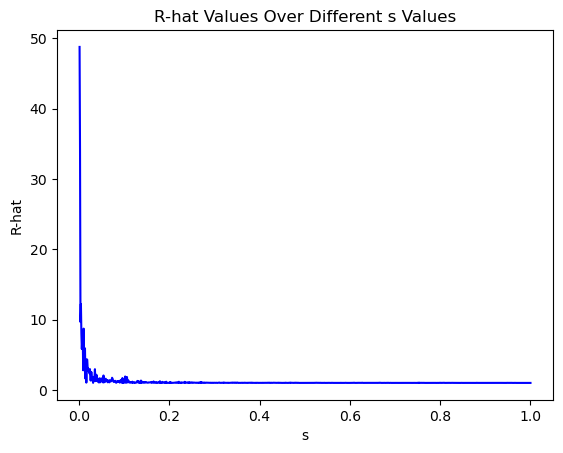

In [13]:
#Plot R-hat values over different s values to visualise the relationship between them

plt.plot(s_values[:len(r_hat_values)], r_hat_values, color='blue')
plt.xlabel('s')
plt.ylabel('R-hat')
plt.title('R-hat Values Over Different s Values')
plt.show()

In [14]:
# Filter R-hat values below 1.05

filtered_r_hat_values = [r_hat for r_hat in r_hat_values if r_hat < 1.05]

print(filtered_r_hat_values)

[1.0421584366226837, 1.0098937429431505, 1.0200575063147082, 1.0481820206671242, 1.0152477205436363, 1.0315729301808323, 1.030874247655991, 1.0479223106935278, 1.0487296203403218, 1.0262634702131328, 1.0243680700032718, 1.0353054918346782, 1.0398968782973508, 1.0407523432189527, 1.0043933196015171, 1.0241690425555008, 1.0372091483937507, 1.044556963945894, 1.0232508341040232, 1.0167553578657693, 1.0125390773056662, 1.0229601231113745, 1.034759998118549, 1.027985150336318, 1.0353748038689805, 1.0371191517328493, 1.0462043900965892, 1.0112366771899837, 1.0251588651207886, 1.044846786706973, 1.002752610134201, 1.0372428766448643, 1.045849945734224, 1.017288006759057, 1.0048130989107742, 1.01006133731487, 1.0343216302087694, 1.0481217207874032, 1.015490709112608, 1.000420740133064, 1.0182509167317462, 1.0043968894677977, 1.0060217676771683, 1.0209214480736262, 1.0148164476946044, 1.0139592072564112, 1.0099635317972, 1.0186587547670194, 1.0169549246066754, 1.0195803382104927, 1.016268142508

### Plot Filtered R-hat values over a grid of s values

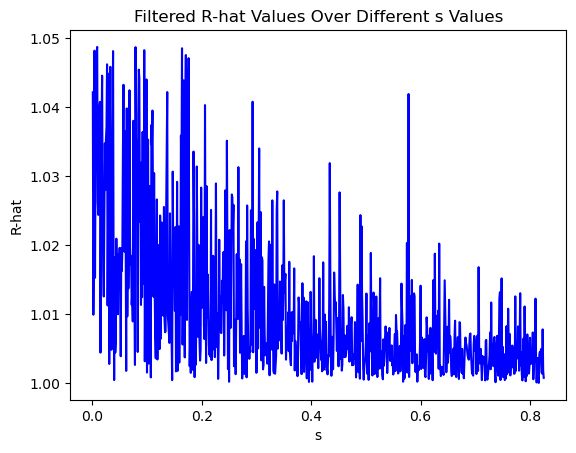

In [15]:
#Plot filtered R-hat values over different s values to visualise the relationship between them

plt.plot(s_values[:len(filtered_r_hat_values)], filtered_r_hat_values, color='blue')
plt.xlabel('s')
plt.ylabel('R-hat')
plt.title('Filtered R-hat Values Over Different s Values')
plt.show()